# Sparse Fourier reconstruction

This notebook demonstrates compressed-sensing style reconstruction by composing three MiniOps operators:

$$
A = R P^* F,
$$

where `F` is a multidimensional FFT operator, `P'` removes Fourier padding after transformation, and `R` keeps only the observed traces. ISTA estimates a sparse Fourier-domain representation.

The first example is a 2-D gather. The second repeats the same construction for a 3-D seismic volume.

In [2]:
using Pkg
Pkg.activate("..")

using MiniOps
using Random
using LinearAlgebra
using Printf
using CairoMakie
using SeisProcessing

  Activating project at `~/MiniOps`


## Helper for seismic image panels

The demos use CairoMakie consistently. MiniOps itself remains independent of plotting; CairoMakie is simply the visualization convention used by the documentation and demos.

In [24]:
function seismic_panel!(figpos, data, t; title="", crange=nothing, color=:seismic)

    nt, nx = size(data)
    ax = Axis(figpos, xlabel="Trace", ylabel="Time (s)", title=title,
              yreversed=true)
    kwargs = isnothing(crange) ? (; colormap=color) : (; colormap=color, colorrange=crange)
    heatmap!(ax, 1:nx, t, data'; kwargs...)
    return ax
end

seismic_panel! (generic function with 1 method)

## 1. 2-D reconstruction

We randomly retain a subset of complete traces. The missing traces are zero in `R' * y`; the reconstruction is obtained by solving for sparse Fourier coefficients.

In [5]:
Random.seed!(11)
d = SeisHypEvents(nt=256, nx=128, dx=10.0,
                  vel=[4000.0,5000.0], tau=[0.32,0.40],
                  apex=[200.0,400.0], amp=[1.0,-1.0])

nt, nx = size(d)
dt = 0.004
t = (0:nt-1) .* dt
amax = maximum(abs.(d))

ns = 80
idx = sort(randperm(nx)[1:ns])
R = trace_sampling_op(idx, size(d))

p = 32
P = pad_op(size(d), (p,p), (p,p))
F = fft_op(zeros(ComplexF64, nt+2p, nx+2p))

# Forward map from Fourier coefficients to observed traces.
A = R * P' * F
y = R * d

opn = opnorm_power(A, randn(ComplexF64, nt+2p, nx+2p))
η = 0.98 / opn^2
coef = ista(A, y, zeros(ComplexF64, nt+2p, nx+2p), 0.003, η;
            niter=300, verbose=true)

drec = real.(P' * F * coef)
dsampled = R' * y

println("SNR = ", 20 * log10(norm(d) / norm(d-drec)), " dB")


ISTA
    iter     rel_residual         residual             cost
------------------------------------------------------------
       0     1.000000e+00     2.433796e+01     2.961682e+02
      20     1.484028e-02     3.611823e-01     5.102363e+00
      40     1.453079e-02     3.536498e-01     4.366144e+00
      60     1.422487e-02     3.462043e-01     3.872278e+00
      80     1.407090e-02     3.424571e-01     3.513808e+00
     100     1.390632e-02     3.384515e-01     3.247420e+00
     120     1.379681e-02     3.357863e-01     3.044687e+00
     140     1.375591e-02     3.347909e-01     2.892404e+00
     160     1.370179e-02     3.334737e-01     2.783687e+00
     180     1.360920e-02     3.312203e-01     2.713513e+00
     200     1.347473e-02     3.279476e-01     2.671568e+00
     220     1.334726e-02     3.248452e-01     2.648980e+00
     240     1.324289e-02     3.223049e-01     2.637104e+00
     260     1.316242e-02     3.203466e-01     2.628811e+00
     280     1.310188e-02     3.1

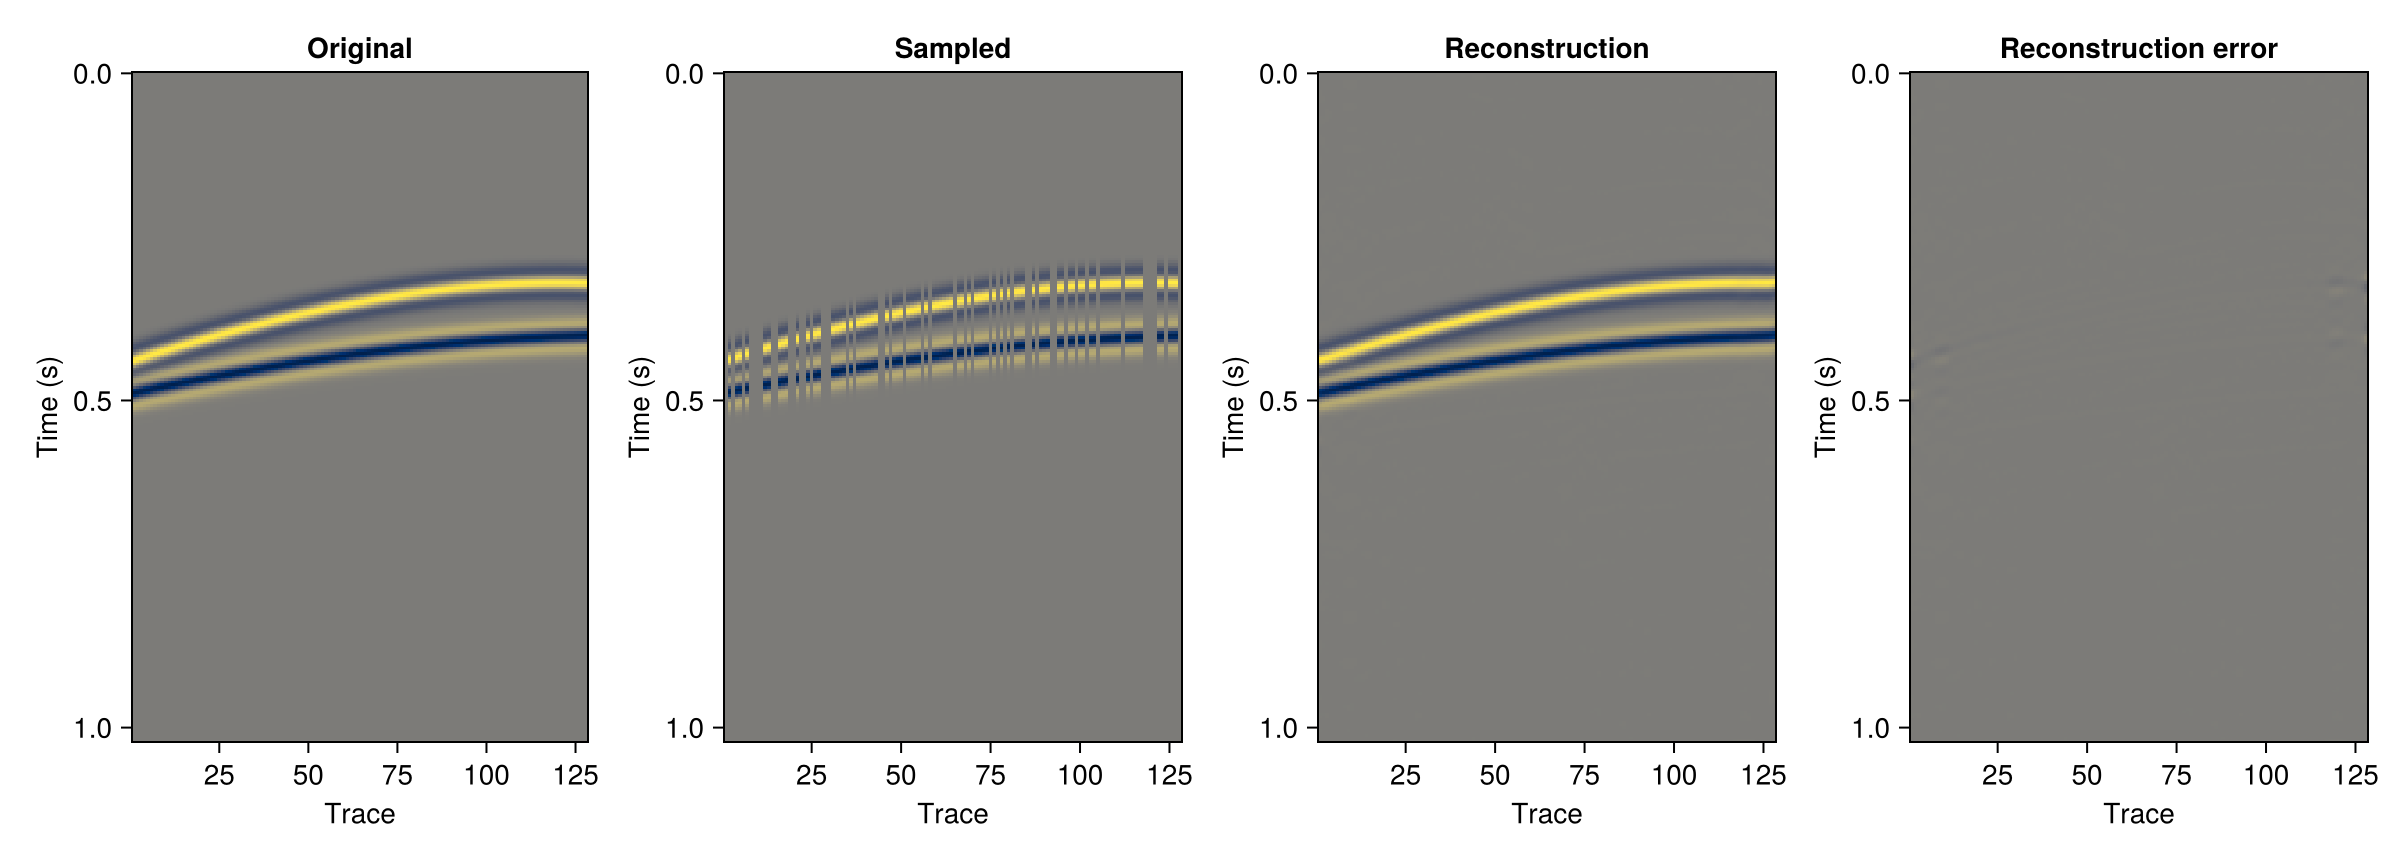

In [30]:
fig = Figure(size=(1200,430))
cr = (-amax, amax)
seismic_panel!(fig[1,1], d,         t; title="Original",            crange=cr, color=:cividis)
seismic_panel!(fig[1,2], dsampled,  t; title="Sampled",             crange=cr, color=:cividis)
seismic_panel!(fig[1,3], drec,      t; title="Reconstruction",      crange=cr, color=:cividis)
seismic_panel!(fig[1,4], drec-d,    t; title="Reconstruction error",crange=cr, color=:cividis)
fig

## 2. 3-D reconstruction

The same operator algebra extends directly to higher dimensions. Trace indices now refer to flattened `(x,y)` positions, but the first dimension remains time.

In [6]:
Random.seed!(12)
d3 = SeisParabEvents(nt=256, nx1=32, nx2=34,
                     p1=[0.1,4.0], p2=[2.3,-0.1],
                     tau=[0.32,0.40], amp=[1.0,-1.0])

nt, nx, ny = size(d3)
dt = 0.004
t = (0:nt-1) .* dt
amax3 = maximum(abs.(d3))

ns = 500
idx = sort(randperm(nx*ny)[1:ns])
R3 = trace_sampling_op(idx, size(d3))
y3 = R3 * d3
d03 = R3' * y3

pt, px, py = 16, 4, 4
P3 = pad_op(size(d3), (pt,px,py), (pt,px,py))
F3 = fft_op(zeros(ComplexF64, nt+2pt, nx+2px, ny+2py))
A3 = R3 * P3' * F3

opn3 = opnorm_power(A3, randn(ComplexF64, nt+2pt, nx+2px, ny+2py))
η3 = 0.98 / opn3^2
coef3 = ista(A3, y3, zeros(ComplexF64, nt+2pt, nx+2px, ny+2py), 0.006, η3;
             niter=200, verbose=true)
drec3 = real.(P3' * F3 * coef3)

println("3-D SNR = ", 20 * log10(norm(d3) / norm(d3-drec3)), " dB")


ISTA
    iter     rel_residual         residual             cost
------------------------------------------------------------
       0     1.000000e+00     6.081096e+01     1.848987e+03
      20     3.392586e-02     2.063064e+00     7.815297e+01
      40     3.294324e-02     2.003310e+00     6.815030e+01
      60     3.236892e-02     1.968385e+00     6.236708e+01
      80     3.202060e-02     1.947204e+00     5.871736e+01
     100     3.177361e-02     1.932184e+00     5.630465e+01
     120     3.161210e-02     1.922362e+00     5.466848e+01
     140     3.149781e-02     1.915412e+00     5.353387e+01
     160     3.140249e-02     1.909615e+00     5.273554e+01
     180     3.132338e-02     1.904805e+00     5.216822e+01
     200     3.125640e-02     1.900732e+00     5.176425e+01
3-D SNR = 14.537381797474671 dB


We inspect two orthogonal slices through the 3-D volume. The reconstruction code itself is unchanged; only the array dimensionality differs.

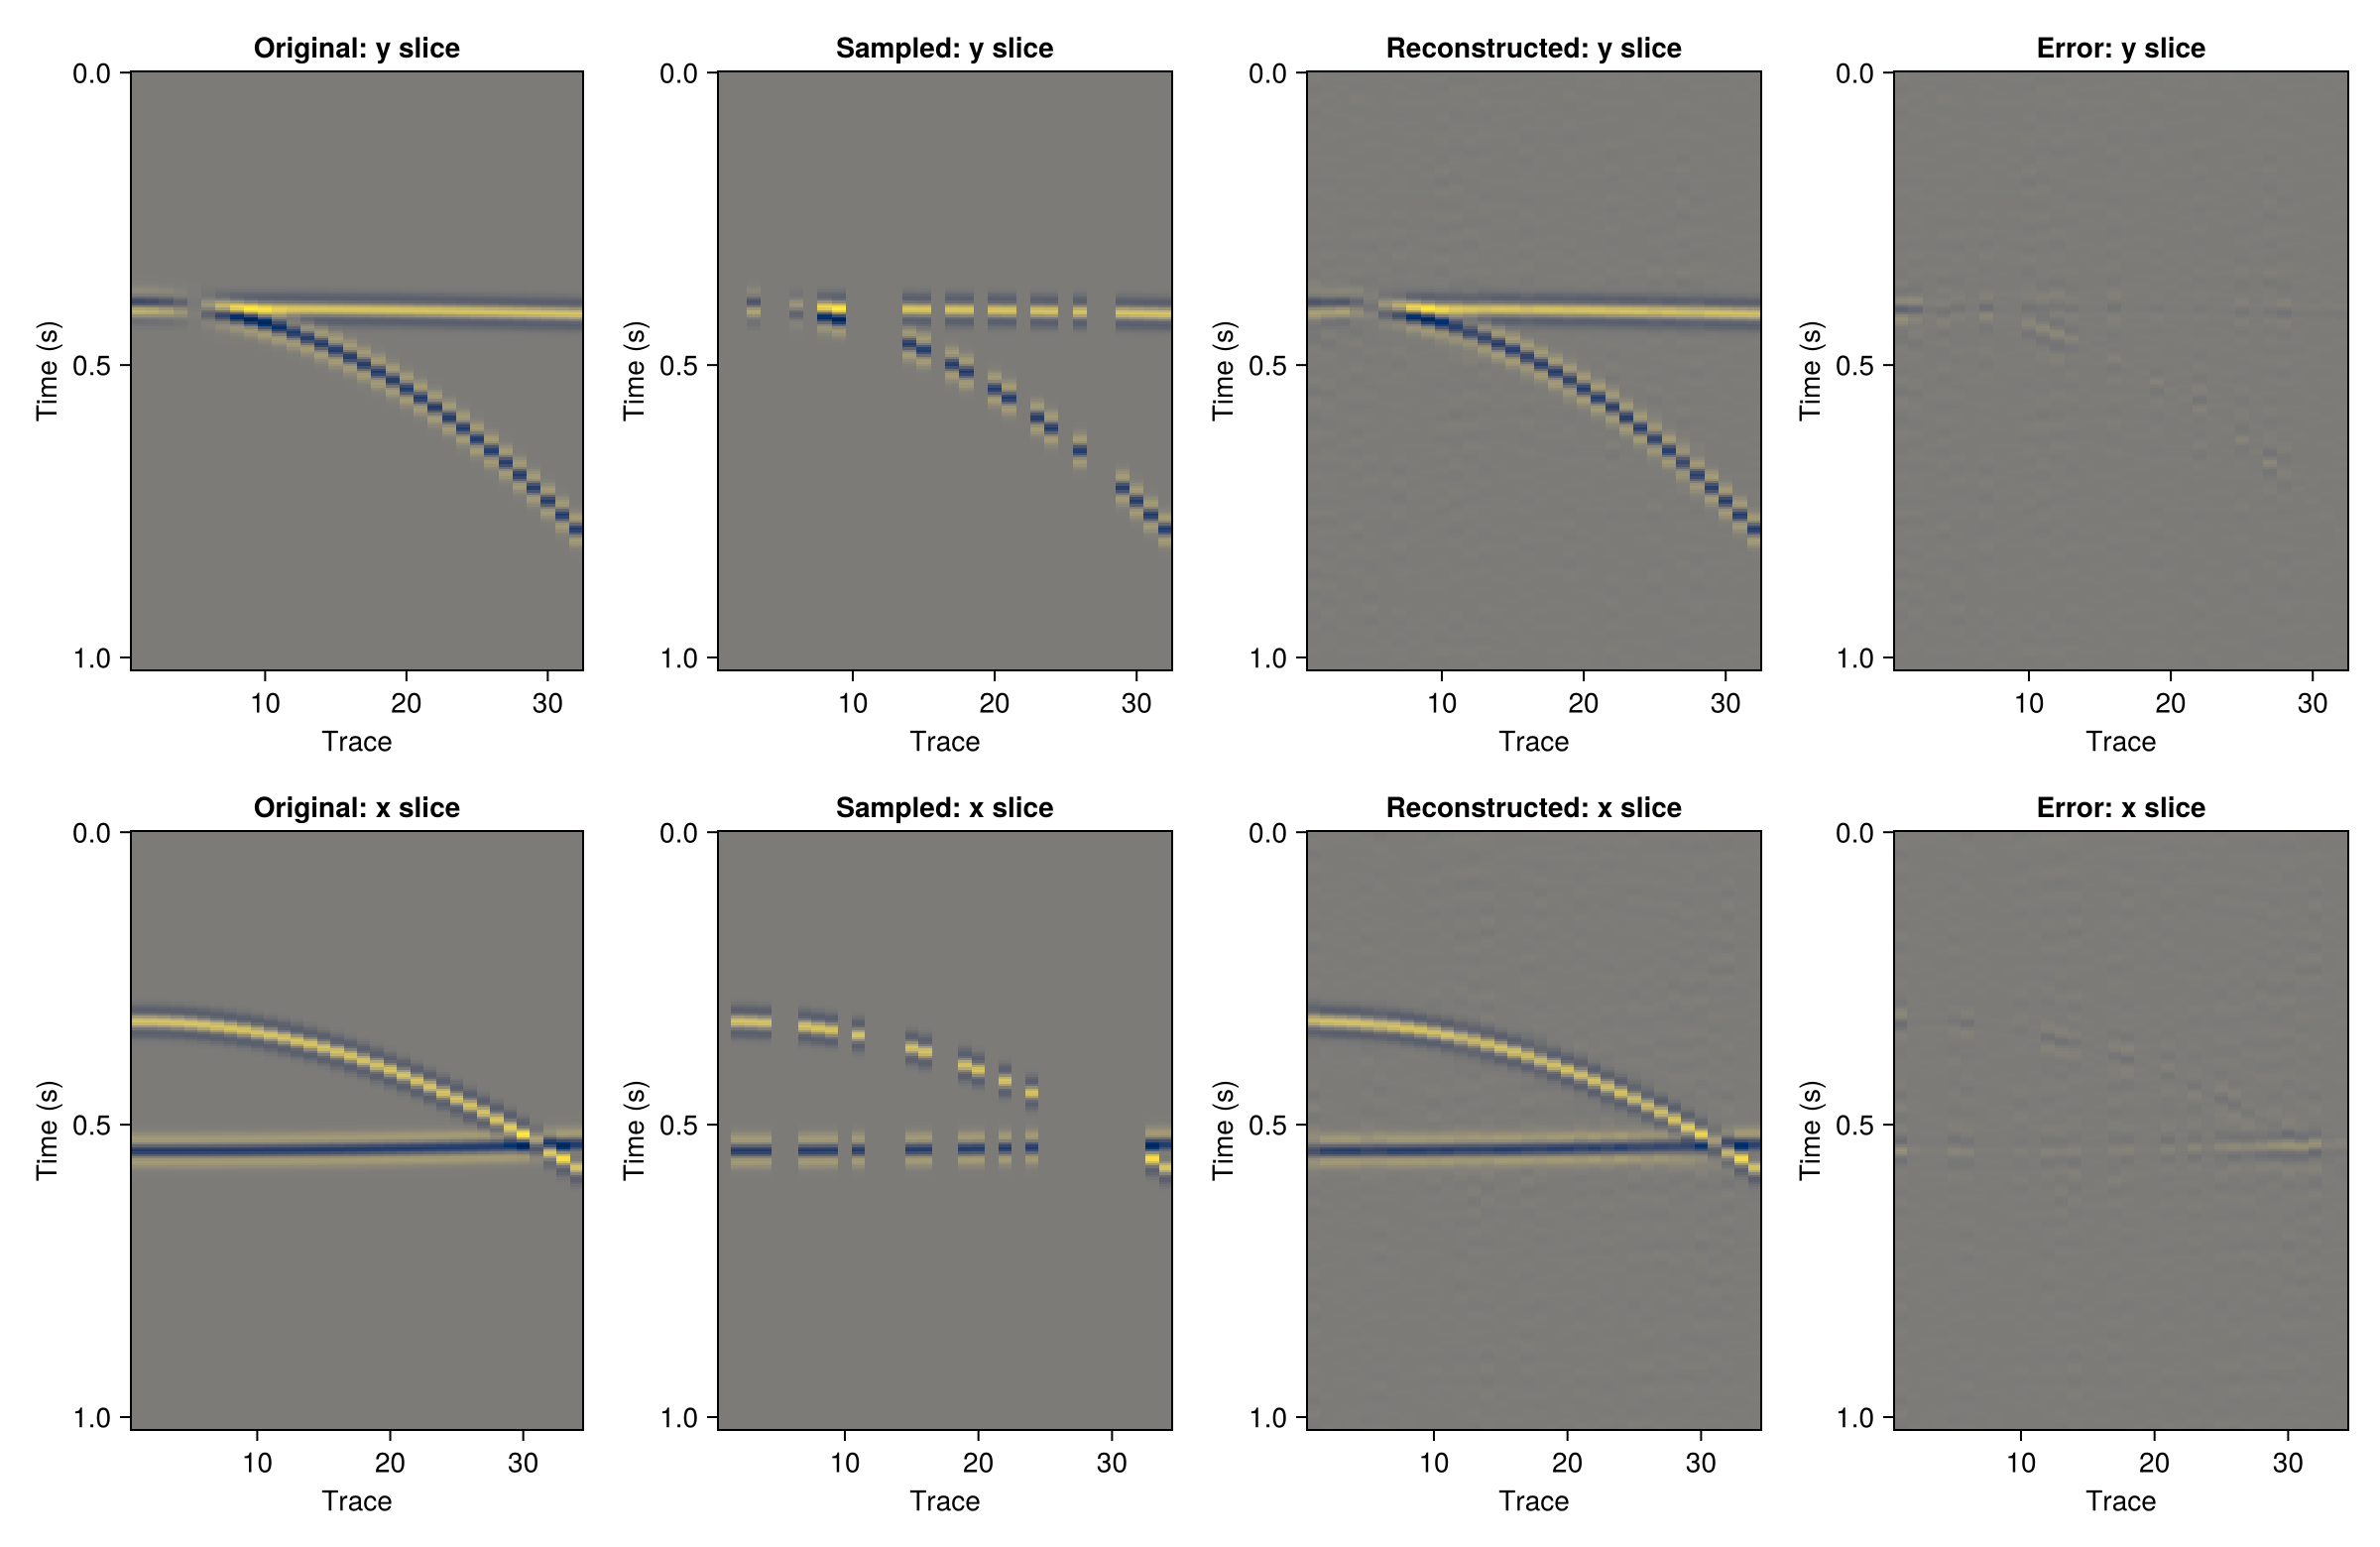

In [34]:
fig = Figure(size=(1200, 780))
cr3 = (-amax3, amax3)

seismic_panel!(fig[1,1], d3[:,:,20],                 t;
    title="Original: y slice", crange=cr3, color=:cividis)
seismic_panel!(fig[1,2], d03[:,:,20],                t;
    title="Sampled: y slice", crange=cr3, color=:cividis)
seismic_panel!(fig[1,3], drec3[:,:,20],              t;
    title="Reconstructed: y slice", crange=cr3, color=:cividis)
seismic_panel!(fig[1,4], drec3[:,:,20] - d3[:,:,20], t;
    title="Error: y slice", crange=cr3, color=:cividis)

seismic_panel!(fig[2,1], d3[:,20,:],                 t;
    title="Original: x slice", crange=cr3, color=:cividis)
seismic_panel!(fig[2,2], d03[:,20,:],                t;
    title="Sampled: x slice", crange=cr3, color=:cividis)
seismic_panel!(fig[2,3], drec3[:,20,:],              t;
    title="Reconstructed: x slice", crange=cr3, color=:cividis)
seismic_panel!(fig[2,4], drec3[:,20,:] - d3[:,20,:], t;
    title="Error: x slice", crange=cr3, color=:cividis)

fig